In [2]:
import requests
import pandas as pd
API_KEY = ""

headers = {
    "": API_KEY
}

url = ""

response = requests.get(
    url,
    headers=headers
)

data = response.json()

data

print(data["errors"])
print(data["results"])

[]
171


In [3]:
url = "" #맨유 데이터 찾기

params = {
    "search": "Manchester United"
}

response = requests.get(
    url,
    headers=headers,
    params=params
)

team_data = response.json()

print(team_data["errors"])
print(team_data["results"])

[]
5


In [4]:
for item in team_data["response"]: #맨유 해당 팀 아이디 확인
    print(
        item["team"]["id"],
        item["team"]["name"],
        item["team"]["country"]
    )

33 Manchester United England
4898 Manchester United W England
7198 Manchester United U21 England
7960 Manchester United U19 England
15382 Manchester United U18 England


In [17]:
TEAM_ID = 33 # 2026 27시즌 프리시즌 데이터 찾기

url = ""

params = {
    "team": TEAM_ID,
    "season": 2026,
    "from": "2026-07-01",
    "to": "2026-08-31"
}

response = requests.get(
    url,
    headers=headers,
    params=params
)

fixtures_data = response.json()

print(fixtures_data["errors"])
print(fixtures_data["results"])
#2026은 무료 플랜에서 사용할수없다.

{'plan': 'Free plans do not have access to this season, try from 2022 to 2024.'}
0


In [5]:
TEAM_ID = 33 #2022 23시즌 데이터 찾기

url = ""

params = {
    "team": TEAM_ID,
    "season": 2022,
    "from": "2022-08-01",
    "to": "2023-05-31"
}

response = requests.get(
    url,
    headers=headers,
    params=params
)

fixtures_data = response.json()

print(fixtures_data["errors"])
print(fixtures_data["results"])#63개의 경기가 데이터로 반환됨

[]
63


In [6]:
for match in fixtures_data["response"]:
    print(
        match["fixture"]["id"],
        match["fixture"]["date"][:10],
        match["teams"]["home"]["name"],
        "vs",
        match["teams"]["away"]["name"],
        "|",
        match["league"]["name"]
    )

867954 2022-08-07 Manchester United vs Brighton | Premier League
867958 2022-08-13 Brentford vs Manchester United | Premier League
867972 2022-08-22 Manchester United vs Liverpool | Premier League
867984 2022-08-27 Southampton vs Manchester United | Premier League
867990 2022-09-01 Leicester vs Manchester United | Premier League
868001 2022-09-04 Manchester United vs Arsenal | Premier League
868008 2023-01-18 Crystal Palace vs Manchester United | Premier League
868021 2023-02-08 Manchester United vs Leeds | Premier League
868033 2022-10-02 Manchester City vs Manchester United | Premier League
868041 2022-10-09 Everton vs Manchester United | Premier League
868052 2022-10-16 Manchester United vs Newcastle | Premier League
868065 2022-10-19 Manchester United vs Tottenham | Premier League
868067 2022-10-22 Chelsea vs Manchester United | Premier League
868084 2022-10-30 Manchester United vs West Ham | Premier League
868086 2022-11-06 Aston Villa vs Manchester United | Premier League
868098 

In [7]:
premier_league_fixtures = []

for match in fixtures_data["response"]:
    if match["league"]["name"] == "Premier League":
        premier_league_fixtures.append(match)

premier_league_fixtures = sorted(
    premier_league_fixtures,
    key=lambda x: x["fixture"]["date"]
)

print(len(premier_league_fixtures))

38


In [8]:
for match in premier_league_fixtures:
    print(
        match["fixture"]["id"],
        match["fixture"]["date"][:10],
        match["teams"]["home"]["name"],
        "vs",
        match["teams"]["away"]["name"]
    )

867954 2022-08-07 Manchester United vs Brighton
867958 2022-08-13 Brentford vs Manchester United
867972 2022-08-22 Manchester United vs Liverpool
867984 2022-08-27 Southampton vs Manchester United
867990 2022-09-01 Leicester vs Manchester United
868001 2022-09-04 Manchester United vs Arsenal
868033 2022-10-02 Manchester City vs Manchester United
868041 2022-10-09 Everton vs Manchester United
868052 2022-10-16 Manchester United vs Newcastle
868065 2022-10-19 Manchester United vs Tottenham
868067 2022-10-22 Chelsea vs Manchester United
868084 2022-10-30 Manchester United vs West Ham
868086 2022-11-06 Aston Villa vs Manchester United
868098 2022-11-13 Fulham vs Manchester United
868114 2022-12-27 Manchester United vs Nottingham Forest
868125 2022-12-31 Wolves vs Manchester United
868134 2023-01-03 Manchester United vs Bournemouth
868141 2023-01-14 Manchester United vs Manchester City
868008 2023-01-18 Crystal Palace vs Manchester United
868147 2023-01-22 Arsenal vs Manchester United
86816

In [9]:
fixture_ids = [
    match["fixture"]["id"]
    for match in premier_league_fixtures
]

fixture_ids

[867954,
 867958,
 867972,
 867984,
 867990,
 868001,
 868033,
 868041,
 868052,
 868065,
 868067,
 868084,
 868086,
 868098,
 868114,
 868125,
 868134,
 868141,
 868008,
 868147,
 868161,
 868021,
 868170,
 868181,
 868201,
 868212,
 868233,
 868192,
 868242,
 868251,
 868269,
 868284,
 868219,
 868294,
 868304,
 868306,
 868264,
 868324]

In [10]:
first_fixture_id = fixture_ids[0]

first_fixture_id

867954

In [11]:
url = ""

params = {
    "fixture": first_fixture_id
}

response = requests.get(
    url,
    headers=headers,
    params=params
    
)

player_data = response.json()

print(player_data["errors"])
print(player_data["results"])

[]
2


In [12]:
player_data["response"]

len(player_data["response"])

for team_block in player_data["response"]:
    print(team_block["team"]["name"])


manutd_block = None

for team_block in player_data["response"]:
    if team_block["team"]["name"] == "Manchester United":
        manutd_block = team_block
        break


manutd_block.keys()

manutd_block["players"][9]

Manchester United
Brighton


{'player': {'id': 174,
  'name': 'Christian Eriksen',
  'photo': 'https://media.api-sports.io/football/players/174.png'},
 'statistics': [{'games': {'minutes': 90,
    'number': 14,
    'position': 'F',
    'rating': '7.2',
    'captain': False,
    'substitute': False},
   'offsides': None,
   'shots': {'total': 2, 'on': 2},
   'goals': {'total': None, 'conceded': 0, 'assists': None, 'saves': None},
   'passes': {'total': 59, 'key': 3, 'accuracy': '44'},
   'tackles': {'total': 2, 'blocks': 1, 'interceptions': None},
   'duels': {'total': 7, 'won': 3},
   'dribbles': {'attempts': None, 'success': None, 'past': 1},
   'fouls': {'drawn': 1, 'committed': None},
   'cards': {'yellow': 0, 'red': 0},
   'penalty': {'won': None,
    'commited': None,
    'scored': 0,
    'missed': 0,
    'saved': None}}]}

In [40]:
for item in manutd_block["players"]:
    position = item["statistics"][0]["games"]["position"]

    if position != "G":
        print(item["player"]["name"])
        print(item["statistics"][0])
        break

stats = manutd_block["players"][1]["statistics"][0]

stats.keys()

Diogo Dalot
{'games': {'minutes': 90, 'number': 20, 'position': 'D', 'rating': '6.7', 'captain': False, 'substitute': False}, 'offsides': None, 'shots': {'total': 2, 'on': 2}, 'goals': {'total': None, 'conceded': 0, 'assists': None, 'saves': None}, 'passes': {'total': 48, 'key': 2, 'accuracy': '37'}, 'tackles': {'total': 1, 'blocks': None, 'interceptions': 3}, 'duels': {'total': 8, 'won': 5}, 'dribbles': {'attempts': 2, 'success': None, 'past': None}, 'fouls': {'drawn': 1, 'committed': None}, 'cards': {'yellow': 0, 'red': 0}, 'penalty': {'won': None, 'commited': None, 'scored': 0, 'missed': 0, 'saved': None}}


dict_keys(['games', 'offsides', 'shots', 'goals', 'passes', 'tackles', 'duels', 'dribbles', 'fouls', 'cards', 'penalty'])

In [13]:
fixture_id = first_fixture_id
match = premier_league_fixtures[0]

date = match["fixture"]["date"][:10]

if match["teams"]["home"]["name"] == "Manchester United":
    opponent = match["teams"]["away"]["name"]
else:
    opponent = match["teams"]["home"]["name"]

rows = []

for item in manutd_block["players"]:

    p = item["player"]
    s = item["statistics"][0]

    rows.append({
        "fixture_id": fixture_id,
        "date": date,
        "opponent": opponent,

        "player_id": p["id"],
        "player": p["name"],

        "position": s["games"]["position"],
        "minutes": s["games"]["minutes"],
        "rating": s["games"]["rating"],

        "goals": s["goals"]["total"],
        "assists": s["goals"]["assists"],

        "shots": s["shots"]["total"],
        "shots_on_target": s["shots"]["on"],

        "passes": s["passes"]["total"],
        "key_passes": s["passes"]["key"],
        "passes_accuracy_raw": s["passes"]["accuracy"],

        "tackles": s["tackles"]["total"],
        "blocks": s["tackles"]["blocks"],
        "interceptions": s["tackles"]["interceptions"],

        "duels": s["duels"]["total"],
        "duels_won": s["duels"]["won"],

        "dribble_attempts": s["dribbles"]["attempts"],
        "dribble_success": s["dribbles"]["success"]
    })

first_match_df = pd.DataFrame(rows)

first_match_df

first_match_df.shape
first_match_df.dtypes
first_match_df.isnull().sum()

fixture_id              0
date                    0
opponent                0
player_id               0
player                  0
position                0
minutes                 4
rating                  7
goals                  20
assists                20
shots                  13
shots_on_target        17
passes                  5
key_passes             13
passes_accuracy_raw     6
tackles                13
blocks                 17
interceptions          13
duels                   7
duels_won               8
dribble_attempts       14
dribble_success        17
dtype: int64

In [14]:
first_match_df[[
    "player",
    "position",
    "minutes",
    "goals",
    "shots",
    "passes",
    "passes_accuracy_raw",
    "tackles",
    "interceptions",
    "dribble_attempts",
    "dribble_success"
]]

,player,position,minutes,goals,shots,passes,passes_accuracy_raw,tackles,interceptions,dribble_attempts,dribble_success
0,David De Gea,G,90.0,None,NaN,26.0,21,NaN,NaN,NaN,NaN
1,Diogo Dalot,D,90.0,None,2.0,48.0,37,1.0,3.0,2.0,NaN
2,Harry Maguire,D,90.0,None,NaN,72.0,63,1.0,4.0,NaN,NaN
3,Lisandro Martínez,D,90.0,None,1.0,80.0,75,2.0,1.0,1.0,1.0
4,Luke Shaw,D,89.0,None,1.0,59.0,47,3.0,2.0,NaN,NaN
5,Scott McTominay,M,78.0,None,NaN,27.0,18,NaN,2.0,1.0,NaN
6,Fred,M,53.0,None,1.0,41.0,33,NaN,2.0,NaN,NaN
7,Bruno Fernandes,M,89.0,None,1.0,64.0,52,NaN,NaN,3.0,2.0
8,Jadon Sancho,F,89.0,None,NaN,31.0,27,NaN,NaN,3.0,2.0
9,Christian Eriksen,F,90.0,None,2.0,59.0,44,2.0,NaN,NaN,NaN


In [17]:
played_df["passes_accuracy_num"] = pd.to_numeric(
    played_df["passes_accuracy_raw"],
    errors="coerce"
)

played_df["passes_num"] = pd.to_numeric(
    played_df["passes"],
    errors="coerce"
)

played_df[[
    "passes_accuracy_raw",
    "passes_accuracy_num",
    "passes_num"
]].dtypes

played_df["pass_success_rate"] = (
    played_df["passes_accuracy_num"]
    / played_df["passes_num"]
    * 100
).round(1)

played_df[[
    "player",
    "passes_num",
    "passes_accuracy_num",
    "pass_success_rate"
]]

NameError: name 'played_df' is not defined

In [33]:
played_df["pass_accuracy_pct"] = pd.to_numeric(
    played_df["passes_accuracy_raw"],
    errors="coerce"
)
played_df[[
    "player",
    "passes",
    "pass_accuracy_pct"
]]

NameError: name 'played_df' is not defined

In [26]:
played_df.drop(columns=["pass_success_rate"], inplace=True)

played_df["pass_accuracy_pct"] = pd.to_numeric(
    played_df["passes_accuracy_raw"],
    errors="coerce"
)

played_df.isnull().sum()

fixture_id              0
date                    0
opponent                0
player_id               0
player                  0
position                0
minutes                 0
rating                  3
goals                  16
assists                16
shots                   9
shots_on_target        13
passes                  1
key_passes              9
passes_accuracy_raw     2
tackles                 9
blocks                 13
interceptions           9
duels                   3
duels_won               4
dribble_attempts       10
dribble_success        13
passes_accuracy_num     2
passes_num              1
pass_accuracy_pct       2
dtype: int64

In [27]:
test_fixture_id = 867972

url = "https://v3.football.api-sports.io/fixtures/players"

params = {
    "fixture": test_fixture_id
}

response = requests.get(
    url,
    headers=headers,
    params=params
)

test_data = response.json()

print(test_data["errors"])
print(test_data["results"])

[]
2


In [30]:
for team_block in test_data["response"]:

    if team_block["team"]["name"] != "Manchester United":
        continue

    for item in team_block["players"]:

        player = item["player"]["name"]
        stats = item["statistics"][0]

        print(
            player,
            "goals =", stats["goals"]["total"],
            "assists =", stats["goals"]["assists"]
        )

David De Gea goals = None assists = None
Diogo Dalot goals = None assists = None
Raphaël Varane goals = None assists = None
Lisandro Martínez goals = None assists = None
Tyrell Malacia goals = None assists = None
Scott McTominay goals = None assists = None
Christian Eriksen goals = None assists = None
Jadon Sancho goals = 1 assists = None
Bruno Fernandes goals = None assists = None
Anthony Elanga goals = None assists = 1
Marcus Rashford goals = 1 assists = None
Tom Heaton goals = None assists = None
Aaron Wan-Bissaka goals = None assists = None
Harry Maguire goals = None assists = None
Luke Shaw goals = None assists = None
Fred goals = None assists = None
Donny van de Beek goals = None assists = None
Cristiano Ronaldo goals = None assists = None
Alejandro Garnacho goals = None assists = None
Anthony Martial goals = None assists = 1


In [35]:
analysis_df = played_df.copy()

analysis_df["goals"] = (
    pd.to_numeric(analysis_df["goals"], errors="coerce")
    .fillna(0)
    .astype(int)
)

analysis_df["assists"] = (
    pd.to_numeric(analysis_df["assists"], errors="coerce")
    .fillna(0)
    .astype(int)
)

analysis_df[["player", "goals", "assists"]]
analysis_df[["goals", "assists"]].dtypes
analysis_df[["player", "goals", "assists"]]

,player,goals,assists
0,David De Gea,0,0
1,Diogo Dalot,0,0
2,Harry Maguire,0,0
3,Lisandro Martínez,0,0
4,Luke Shaw,0,0
5,Scott McTominay,0,0
6,Fred,0,0
7,Bruno Fernandes,0,0
8,Jadon Sancho,0,0
9,Christian Eriksen,0,0


In [11]:
def get_manutd_player_stats(fixture_id):
    #1 API요청
    url = ""

    params = {
        "fixture": fixture_id
    }
    response = requests.get(
    url,
    headers=headers,
    params=params
    )
    data = response.json()
    #2. 맨유 블록 추출
    manutd_block = None

    for team_block in data["response"]:
        if team_block["team"]["name"] == "Manchester United":
            manutd_block = team_block
            break
    #3. 선수 데이터 rows에 저장
    rows = []
    #4. 선수 목록 반복
    for item in manutd_block["players"]:
        player_info = item["player"]
        stats = item["statistics"][0]
    
        rows.append({
            "fixture_id": fixture_id,
            "player_id": player_info["id"],
            "player": player_info["name"],
            "position": stats["games"]["position"],
            "minutes": stats["games"]["minutes"],
            "rating": stats["games"]["rating"],
            "goals": stats["goals"]["total"],
            "assists": stats["goals"]["assists"],
            "shots": stats["shots"]["total"],
            "shots_on_target": stats["shots"]["on"],
            "passes": stats["passes"]["total"],
            "key_passes": stats["passes"]["key"],
            "passes_accuracy_raw": stats["passes"]["accuracy"],
            "tackles": stats["tackles"]["total"],
            "blocks": stats["tackles"]["blocks"],
            "interceptions": stats["tackles"]["interceptions"],
            "duels": stats["duels"]["total"],
            "duels_won": stats["duels"]["won"],
            "dribble_attempts": stats["dribbles"]["attempts"],
            "dribble_success": stats["dribbles"]["success"]
            })

    #5. DataFrame
    df=pd.DataFrame(rows)
    #6. 미출전 선수 제거
    df = df[
    df["minutes"].notna()
    & (df["minutes"] > 0)
    ].copy()
    #7. goals 정제
    df["goals"] = (
    pd.to_numeric(df["goals"], errors="coerce")
    .fillna(0)
    .astype(int)
    )
    # 8. assists 정제
    df["assists"]=(
    pd.to_numeric(df["assists"], errors="coerce")
    .fillna(0)
    .astype(int)
    )
    #9. 패스 정확도 정제
    df["pass_accuracy_pct"] = pd.to_numeric(
    df["passes_accuracy_raw"],
    errors="coerce"
    )
    return df

In [12]:
test_df=get_manutd_player_stats(867954)
test_df

,fixture_id,player_id,player,position,minutes,rating,goals,assists,shots,shots_on_target,...,key_passes,passes_accuracy_raw,tackles,blocks,interceptions,duels,duels_won,dribble_attempts,dribble_success,pass_accuracy_pct
0,867954,882,David De Gea,G,90.0,6.2,0,0,NaN,NaN,...,NaN,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.0
1,867954,886,Diogo Dalot,D,90.0,6.7,0,0,2.0,2.0,...,2.0,37,1.0,NaN,3.0,8.0,5.0,2.0,NaN,37.0
2,867954,2935,Harry Maguire,D,90.0,7,0,0,NaN,NaN,...,NaN,63,1.0,1.0,4.0,5.0,3.0,NaN,NaN,63.0
3,867954,2467,Lisandro Martínez,D,90.0,7.2,0,0,1.0,NaN,...,NaN,75,2.0,2.0,1.0,8.0,5.0,1.0,1.0,75.0
4,867954,891,Luke Shaw,D,89.0,7,0,0,1.0,1.0,...,2.0,47,3.0,NaN,2.0,9.0,5.0,NaN,NaN,47.0
5,867954,903,Scott McTominay,M,78.0,6.2,0,0,NaN,NaN,...,NaN,18,NaN,NaN,2.0,7.0,4.0,1.0,NaN,18.0
6,867954,905,Fred,M,53.0,6.2,0,0,1.0,NaN,...,NaN,33,NaN,NaN,2.0,4.0,NaN,NaN,NaN,33.0
7,867954,1485,Bruno Fernandes,M,89.0,7.3,0,0,1.0,NaN,...,2.0,52,NaN,NaN,NaN,9.0,5.0,3.0,2.0,52.0
8,867954,18,Jadon Sancho,F,89.0,7,0,0,NaN,NaN,...,2.0,27,NaN,NaN,NaN,3.0,2.0,3.0,2.0,27.0
9,867954,174,Christian Eriksen,F,90.0,7.2,0,0,2.0,2.0,...,3.0,44,2.0,1.0,NaN,7.0,3.0,NaN,NaN,44.0


In [13]:
test_df2 = get_manutd_player_stats(867972)
test_df2

,fixture_id,player_id,player,position,minutes,rating,goals,assists,shots,shots_on_target,...,key_passes,passes_accuracy_raw,tackles,blocks,interceptions,duels,duels_won,dribble_attempts,dribble_success,pass_accuracy_pct
0,867972,882,David De Gea,G,90.0,7.5,0,0,NaN,NaN,...,NaN,7,NaN,NaN,NaN,1.0,1.0,NaN,NaN,7.0
1,867972,886,Diogo Dalot,D,86.0,7.2,0,0,NaN,NaN,...,2.0,15,3.0,1.0,3.0,11.0,5.0,NaN,NaN,15.0
2,867972,742,Raphaël Varane,D,90.0,7.2,0,0,NaN,NaN,...,1.0,16,4.0,NaN,2.0,8.0,6.0,NaN,NaN,16.0
3,867972,2467,Lisandro Martínez,D,90.0,7.2,0,0,NaN,NaN,...,NaN,18,1.0,3.0,1.0,5.0,1.0,NaN,NaN,18.0
4,867972,37145,Tyrell Malacia,D,90.0,6.9,0,0,NaN,NaN,...,NaN,15,5.0,NaN,1.0,11.0,6.0,1.0,NaN,15.0
5,867972,903,Scott McTominay,M,90.0,6.9,0,0,NaN,NaN,...,NaN,19,3.0,NaN,2.0,13.0,7.0,2.0,2.0,19.0
6,867972,174,Christian Eriksen,M,86.0,6.6,0,0,2.0,1.0,...,NaN,15,NaN,1.0,NaN,5.0,2.0,1.0,1.0,15.0
7,867972,18,Jadon Sancho,M,71.0,7.7,1,0,1.0,1.0,...,1.0,19,1.0,NaN,NaN,4.0,3.0,3.0,2.0,19.0
8,867972,1485,Bruno Fernandes,M,90.0,7.3,0,0,1.0,1.0,...,2.0,25,3.0,NaN,3.0,15.0,6.0,NaN,NaN,25.0
9,867972,153430,Anthony Elanga,M,45.0,6.9,0,1,1.0,NaN,...,1.0,9,1.0,NaN,NaN,5.0,3.0,2.0,NaN,9.0


In [21]:
premier_league_fixtures = []

for match in fixtures_data["response"]:
    if match["league"]["name"] == "Premier League":
        premier_league_fixtures.append(match)

premier_league_fixtures = sorted(
    premier_league_fixtures,
    key=lambda x: x["fixture"]["date"]
)

print(len(premier_league_fixtures))
fixture_ids = [
    match["fixture"]["id"]
    for match in premier_league_fixtures
]

fixture_ids

38


[867954,
 867958,
 867972,
 867984,
 867990,
 868001,
 868033,
 868041,
 868052,
 868065,
 868067,
 868084,
 868086,
 868098,
 868114,
 868125,
 868134,
 868141,
 868008,
 868147,
 868161,
 868021,
 868170,
 868181,
 868201,
 868212,
 868233,
 868192,
 868242,
 868251,
 868269,
 868284,
 868219,
 868294,
 868304,
 868306,
 868264,
 868324]

In [22]:
#fixture_ids에 38경기가 있는지 확인하기
print(len(fixture_ids))
print(fixture_ids[:5])

38
[867954, 867958, 867972, 867984, 867990]


In [23]:
#앞선 두경기만 가져오기
season_dfs=[]

for fixture_id in fixture_ids[:2]:
    match_df = get_manutd_player_stats(fixture_id)
    season_dfs.append(match_df)

In [24]:
#데이터프레임 합치기
season_df = pd.concat(
    season_dfs,
    ignore_index=True
)

In [25]:
#확인
len(season_df)
season_df.head()

,fixture_id,player_id,player,position,minutes,rating,goals,assists,shots,shots_on_target,...,key_passes,passes_accuracy_raw,tackles,blocks,interceptions,duels,duels_won,dribble_attempts,dribble_success,pass_accuracy_pct
0,867954,882,David De Gea,G,90.0,6.2,0,0,NaN,NaN,...,NaN,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.0
1,867954,886,Diogo Dalot,D,90.0,6.7,0,0,2.0,2.0,...,2.0,37,1.0,NaN,3.0,8.0,5.0,2.0,NaN,37.0
2,867954,2935,Harry Maguire,D,90.0,7,0,0,NaN,NaN,...,NaN,63,1.0,1.0,4.0,5.0,3.0,NaN,NaN,63.0
3,867954,2467,Lisandro Martínez,D,90.0,7.2,0,0,1.0,NaN,...,NaN,75,2.0,2.0,1.0,8.0,5.0,1.0,1.0,75.0
4,867954,891,Luke Shaw,D,89.0,7,0,0,1.0,1.0,...,2.0,47,3.0,NaN,2.0,9.0,5.0,NaN,NaN,47.0


In [26]:
season_df["fixture_id"].unique()

array([867954, 867958])

In [33]:
def get_manutd_player_stats(fixture_id):

    url = ""

    params = {
        "fixture": fixture_id
    }

    response = requests.get(
        url,
        headers=headers,
        params=params
    )

    data = response.json()

    # 맨유 블록 찾기
    manutd_block = None

    for team_block in data["response"]:
        if team_block["team"]["name"] == "Manchester United":
            manutd_block = team_block
            break

    if manutd_block is None:
        print(f"맨유 데이터 없음: {fixture_id}")
        return pd.DataFrame()

    # 선수 데이터 저장
    rows = []

    for item in manutd_block["players"]:

        player_info = item["player"]
        stats = item["statistics"][0]

        rows.append({
            "fixture_id": fixture_id,
            "player_id": player_info["id"],
            "player": player_info["name"],
            "position": stats["games"]["position"],
            "minutes": stats["games"]["minutes"],
            "rating": stats["games"]["rating"],
            "goals": stats["goals"]["total"],
            "assists": stats["goals"]["assists"],
            "shots": stats["shots"]["total"],
            "shots_on_target": stats["shots"]["on"],
            "passes": stats["passes"]["total"],
            "key_passes": stats["passes"]["key"],
            "passes_accuracy_raw": stats["passes"]["accuracy"],
            "tackles": stats["tackles"]["total"],
            "blocks": stats["tackles"]["blocks"],
            "interceptions": stats["tackles"]["interceptions"],
            "duels": stats["duels"]["total"],
            "duels_won": stats["duels"]["won"],
            "dribble_attempts": stats["dribbles"]["attempts"],
            "dribble_success": stats["dribbles"]["success"]
        })

    df = pd.DataFrame(rows)

    # 미출전 선수 제거
    df = df[
        df["minutes"].notna()
        & (df["minutes"] > 0)
    ].copy()

    # 득점 정제
    df["goals"] = (
        pd.to_numeric(df["goals"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    # 도움 정제
    df["assists"] = (
        pd.to_numeric(df["assists"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    # 패스 데이터 숫자형 변환
    df["pass_accuracy_pct"] = pd.to_numeric(
        df["passes_accuracy_raw"],
        errors="coerce"
    )

    return df

In [19]:
print(callable(get_manutd_player_stats))

True


In [34]:
season_dfs = []

for fixture_id in fixture_ids:
    print("현재 경기:", fixture_id)

    match_df = get_manutd_player_stats(fixture_id)
    season_dfs.append(match_df)

현재 경기: 867954
현재 경기: 867958
현재 경기: 867972
현재 경기: 867984
현재 경기: 867990
현재 경기: 868001
현재 경기: 868033
현재 경기: 868041
현재 경기: 868052
현재 경기: 868065
현재 경기: 868067
맨유 데이터 없음: 868067
현재 경기: 868084
맨유 데이터 없음: 868084
현재 경기: 868086
맨유 데이터 없음: 868086
현재 경기: 868098
맨유 데이터 없음: 868098
현재 경기: 868114
맨유 데이터 없음: 868114
현재 경기: 868125
맨유 데이터 없음: 868125
현재 경기: 868134
맨유 데이터 없음: 868134
현재 경기: 868141
맨유 데이터 없음: 868141
현재 경기: 868008
맨유 데이터 없음: 868008
현재 경기: 868147
맨유 데이터 없음: 868147
현재 경기: 868161
맨유 데이터 없음: 868161
현재 경기: 868021
맨유 데이터 없음: 868021
현재 경기: 868170
맨유 데이터 없음: 868170
현재 경기: 868181
맨유 데이터 없음: 868181
현재 경기: 868201
맨유 데이터 없음: 868201
현재 경기: 868212
맨유 데이터 없음: 868212
현재 경기: 868233
맨유 데이터 없음: 868233
현재 경기: 868192
맨유 데이터 없음: 868192
현재 경기: 868242
맨유 데이터 없음: 868242
현재 경기: 868251
맨유 데이터 없음: 868251
현재 경기: 868269
맨유 데이터 없음: 868269
현재 경기: 868284
맨유 데이터 없음: 868284
현재 경기: 868219
맨유 데이터 없음: 868219
현재 경기: 868294
맨유 데이터 없음: 868294
현재 경기: 868304
맨유 데이터 없음: 868304
현재 경기: 868306
맨유 데이터 없음: 868306
현재 경기: 868264
맨유 데이터 없음: 868

In [30]:
url = ""

params = {
    "fixture": 868125
}

response = requests.get(
    url,
    headers=headers,
    params=params
)

check_data = response.json()

print("status:", response.status_code)
print("errors:", check_data["errors"])
print("results:", check_data["results"])

status: 200
errors: []
results: 2


In [31]:
for team_block in check_data["response"]:
    print(team_block["team"]["name"])

Wolves
Manchester United


In [35]:
season_dfs = [
    df for df in season_dfs
    if not df.empty
]

print(len(season_dfs))

10


In [39]:
season_df = pd.concat(
    season_dfs,
    ignore_index=True
)

print("수집 경기 수:", season_df["fixture_id"].nunique())
print("전체 행 수:", len(season_df))

수집 경기 수: 38
전체 행 수: 567


C:\TempFolder\ipykernel_25628\3760820914.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  season_df = pd.concat(


In [38]:
season_dfs = [df for df in season_dfs if not df.empty]
print(len(season_dfs))

38


In [ ]:
import time

for fixture_id in remaining_ids:
    match_df = get_manutd_player_stats(fixture_id)

    if not match_df.empty:
        season_dfs.append(match_df)

    time.sleep(7)

In [40]:
valid_dfs = [
    df for df in season_dfs
    if not df.empty
]

season_df = pd.concat(
    valid_dfs,
    ignore_index=True
)

C:\TempFolder\ipykernel_25628\2009063694.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  season_df = pd.concat(


In [41]:
print("경기 수:", season_df["fixture_id"].nunique())

print(
    "중복 선수-경기 행:",
    season_df.duplicated(
        subset=["fixture_id", "player_id"]
    ).sum()
)

경기 수: 38
중복 선수-경기 행: 0


In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("manutd_2223.db")

In [43]:
season_df.to_sql(
    "player_match_stats",
    conn,
    if_exists="replace",
    index=False
)

567

In [44]:
#테이블 저장
query = """
SELECT *
FROM player_match_stats
LIMIT 5
"""

pd.read_sql_query(query, conn)

,fixture_id,player_id,player,position,minutes,rating,goals,assists,shots,shots_on_target,...,key_passes,passes_accuracy_raw,tackles,blocks,interceptions,duels,duels_won,dribble_attempts,dribble_success,pass_accuracy_pct
0,867954,882,David De Gea,G,90.0,6.2,0,0,NaN,NaN,...,NaN,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.0
1,867954,886,Diogo Dalot,D,90.0,6.7,0,0,2.0,2.0,...,2.0,37,1.0,NaN,3.0,8.0,5.0,2.0,NaN,37.0
2,867954,2935,Harry Maguire,D,90.0,7,0,0,NaN,NaN,...,NaN,63,1.0,1.0,4.0,5.0,3.0,NaN,NaN,63.0
3,867954,2467,Lisandro Martínez,D,90.0,7.2,0,0,1.0,NaN,...,NaN,75,2.0,2.0,1.0,8.0,5.0,1.0,1.0,75.0
4,867954,891,Luke Shaw,D,89.0,7,0,0,1.0,1.0,...,2.0,47,3.0,NaN,2.0,9.0,5.0,NaN,NaN,47.0


In [50]:
#총 득점 순위
query = """
SELECT
    player,
    SUM(goals) AS total_goals
FROM player_match_stats
GROUP BY player
ORDER BY total_goals DESC
"""

pd.read_sql_query(query, conn)

,player,total_goals
0,Marcus Rashford,17
1,Bruno Fernandes,8
2,Jadon Sancho,6
3,Anthony Martial,6
4,Casemiro,4
5,Antony,4
6,Alejandro Garnacho,3
7,Fred,2
8,Scott McTominay,1
9,Luke Shaw,1


In [49]:
#공격 포인트 순위
query = """
SELECT
    player,
    SUM(goals) AS total_goals,
    SUM(assists) AS total_assists,
    SUM(goals+assists) AS total_points
FROM player_match_stats
GROUP BY player
ORDER BY total_points DESC
"""

pd.read_sql_query(query, conn)

,player,total_goals,total_assists,total_points
0,Marcus Rashford,17,5,22
1,Bruno Fernandes,8,8,16
2,Jadon Sancho,6,3,9
3,Christian Eriksen,1,8,9
4,Anthony Martial,6,2,8
5,Casemiro,4,3,7
6,Antony,4,2,6
7,Alejandro Garnacho,3,2,5
8,Fred,2,2,4
9,Luke Shaw,1,2,3


In [52]:
#총 슈팅과 유효슈팅 순위
query = """
SELECT
    player,
    SUM(shots) AS total_shots,
    SUM(shots_on_target) AS total_shots_on_target
FROM player_match_stats
GROUP BY player
ORDER BY total_shots DESC
"""

pd.read_sql_query(query, conn)

,player,total_shots,total_shots_on_target
0,Marcus Rashford,81.0,50.0
1,Bruno Fernandes,70.0,35.0
2,Antony,51.0,24.0
3,Casemiro,28.0,11.0
4,Christian Eriksen,27.0,12.0
5,Anthony Martial,21.0,13.0
6,Cristiano Ronaldo,19.0,6.0
7,Alejandro Garnacho,17.0,10.0
8,Fred,16.0,5.0
9,Jadon Sancho,14.0,11.0


In [53]:
#선수별 총 키패스 순위
query = """
SELECT
    player,
    SUM(key_passes) AS total_key_passes
FROM player_match_stats
GROUP BY player
ORDER BY total_key_passes DESC
"""

pd.read_sql_query(query, conn)

,player,total_key_passes
0,Bruno Fernandes,121.0
1,Jadon Sancho,44.0
2,Christian Eriksen,36.0
3,Luke Shaw,35.0
4,Marcus Rashford,30.0
5,Fred,30.0
6,Diogo Dalot,29.0
7,Casemiro,29.0
8,Antony,29.0
9,Aaron Wan-Bissaka,15.0


In [54]:
#총 패스순위
query = """
SELECT
    player,
    SUM(passes) AS total_passes
FROM player_match_stats
GROUP BY player
ORDER BY total_passes DESC
"""

pd.read_sql_query(query, conn)

,player,total_passes
0,Bruno Fernandes,1856.0
1,Luke Shaw,1806.0
2,Lisandro Martínez,1518.0
3,Casemiro,1412.0
4,Christian Eriksen,1391.0
5,Diogo Dalot,1188.0
6,Raphaël Varane,1099.0
7,David De Gea,1083.0
8,Victor Lindelöf,927.0
9,Marcus Rashford,779.0


In [5]:
query = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(tackles) AS tackles_not_null,
    COUNT(interceptions) AS interceptions_not_null,
    COUNT(blocks) AS blocks_not_null,
    COUNT(duels) AS duels_not_null,
    COUNT(duels_won) AS duels_won_not_null
FROM player_match_stats
"""

pd.read_sql_query(query, conn)

,total_rows,tackles_not_null,interceptions_not_null,blocks_not_null,duels_not_null,duels_won_not_null
0,567,312,227,111,518,470


In [6]:
query = """
SELECT
    fixture_id,
    player,
    position,
    minutes,
    tackles,
    interceptions,
    blocks,
    duels,
    duels_won
FROM player_match_stats
WHERE tackles IS NULL
   OR interceptions IS NULL
   OR blocks IS NULL
   OR duels IS NULL
   OR duels_won IS NULL
LIMIT 20
"""

pd.read_sql_query(query, conn)

,fixture_id,player,position,minutes,tackles,interceptions,blocks,duels,duels_won
0,867954,David De Gea,G,90.0,NaN,NaN,NaN,NaN,NaN
1,867954,Diogo Dalot,D,90.0,1.0,3.0,NaN,8.0,5.0
2,867954,Luke Shaw,D,89.0,3.0,2.0,NaN,9.0,5.0
3,867954,Scott McTominay,M,78.0,NaN,2.0,NaN,7.0,4.0
4,867954,Fred,M,53.0,NaN,2.0,NaN,4.0,NaN
5,867954,Bruno Fernandes,M,89.0,NaN,NaN,NaN,9.0,5.0
6,867954,Jadon Sancho,F,89.0,NaN,NaN,NaN,3.0,2.0
7,867954,Christian Eriksen,F,90.0,2.0,NaN,1.0,7.0,3.0
8,867954,Marcus Rashford,F,90.0,1.0,1.0,NaN,8.0,2.0
9,867954,Tyrell Malacia,D,1.0,2.0,NaN,NaN,5.0,3.0


In [7]:
query = """
SELECT
    SUM(CASE WHEN tackles = 0 THEN 1 ELSE 0 END) AS tackles_zero,
    SUM(CASE WHEN interceptions = 0 THEN 1 ELSE 0 END) AS interceptions_zero,
    SUM(CASE WHEN blocks = 0 THEN 1 ELSE 0 END) AS blocks_zero,
    SUM(CASE WHEN duels = 0 THEN 1 ELSE 0 END) AS duels_zero,
    SUM(CASE WHEN duels_won = 0 THEN 1 ELSE 0 END) AS duels_won_zero,

    MIN(tackles) AS min_tackles,
    MIN(interceptions) AS min_interceptions,
    MIN(blocks) AS min_blocks,
    MIN(duels) AS min_duels,
    MIN(duels_won) AS min_duels_won
FROM player_match_stats
"""

pd.read_sql_query(query, conn)

,tackles_zero,interceptions_zero,blocks_zero,duels_zero,duels_won_zero,min_tackles,min_interceptions,min_blocks,min_duels,min_duels_won
0,0,0,0,0,0,1.0,1.0,1.0,1.0,1.0


In [8]:
#선수별 태클 합계
query = """
SELECT
    player,
    SUM(tackles) AS total_tackles
FROM player_match_stats
GROUP BY player
ORDER BY total_tackles DESC
"""

pd.read_sql_query(query, conn)

,player,total_tackles
0,Casemiro,90.0
1,Bruno Fernandes,68.0
2,Luke Shaw,55.0
3,Lisandro Martínez,54.0
4,Diogo Dalot,54.0
5,Fred,47.0
6,Tyrell Malacia,46.0
7,Aaron Wan-Bissaka,40.0
8,Scott McTominay,32.0
9,Raphaël Varane,24.0


In [9]:
#선수별 인터셉트 합계
query = """
SELECT
    player,
    SUM(interceptions) AS total_interceptions
FROM player_match_stats
GROUP BY player
ORDER BY total_interceptions DESC
"""

pd.read_sql_query(query, conn)

,player,total_interceptions
0,Diogo Dalot,37.0
1,Luke Shaw,36.0
2,Casemiro,34.0
3,Lisandro Martínez,33.0
4,Tyrell Malacia,25.0
5,Bruno Fernandes,25.0
6,Aaron Wan-Bissaka,22.0
7,Victor Lindelöf,21.0
8,Fred,19.0
9,Scott McTominay,14.0


In [10]:
#선수별 블록 합계
query = """
SELECT
    player,
    SUM(blocks) AS total_blocks
FROM player_match_stats
GROUP BY player
ORDER BY total_blocks DESC
"""

pd.read_sql_query(query, conn)

,player,total_blocks
0,Lisandro Martínez,27.0
1,Raphaël Varane,17.0
2,Luke Shaw,17.0
3,Harry Maguire,11.0
4,Casemiro,11.0
5,Victor Lindelöf,9.0
6,Christian Eriksen,9.0
7,Aaron Wan-Bissaka,8.0
8,Diogo Dalot,7.0
9,Scott McTominay,6.0


In [11]:
#선수별 경합과 경합 승리 합계
query = """
SELECT
    player,
    SUM(duels) AS total_duels,
    SUM(duels_won) AS total_duels_won
FROM player_match_stats
GROUP BY player
ORDER BY total_duels DESC
"""

pd.read_sql_query(query, conn)

,player,total_duels,total_duels_won
0,Bruno Fernandes,349.0,156.0
1,Casemiro,320.0,179.0
2,Marcus Rashford,302.0,117.0
3,Luke Shaw,252.0,141.0
4,Fred,189.0,92.0
5,Scott McTominay,183.0,95.0
6,Lisandro Martínez,181.0,110.0
7,Antony,181.0,79.0
8,Diogo Dalot,176.0,114.0
9,Jadon Sancho,161.0,60.0


In [15]:
#선수별 경합 승리
query = """
SELECT
    player,
    SUM(duels) AS total_duels,
    COALESCE(SUM(duels_won),0) AS total_duels_won,
    ROUND(COALESCE(SUM(duels_won), 0) * 100.0 / SUM(duels),1) AS duel_win_pct
FROM player_match_stats
GROUP BY player
ORDER BY duel_win_pct DESC
"""

pd.read_sql_query(query, conn)
#데헤아는 경합 승률이 83.3%로 가장 높지만 전체 경합이 12회에 불과해 다른 선수들보다 표본이 매우 작다. 
#또한 골키퍼와 필드플레이어는 경합이 발생하는 상황과 역할이 다르기 때문에 단순 승률만으로 직접 비교해 최고의 경합 선수라고 판단하기 어렵다.

,player,total_duels,total_duels_won,duel_win_pct
0,David De Gea,12.0,10.0,83.3
1,Diogo Dalot,176.0,114.0,64.8
2,Raphaël Varane,117.0,74.0,63.2
3,Facundo Pellistri,8.0,5.0,62.5
4,Lisandro Martínez,181.0,110.0,60.8
5,Victor Lindelöf,102.0,61.0,59.8
6,Luke Shaw,252.0,141.0,56.0
7,Casemiro,320.0,179.0,55.9
8,Aaron Wan-Bissaka,130.0,72.0,55.4
9,Cristiano Ronaldo,47.0,26.0,55.3


In [6]:
#공격 테이블 만들기
query = """
SELECT
    player,
    SUM(goals) AS total_goals,
    SUM(assists) AS total_assists,
    SUM(goals+assists) AS attack_points,
    SUM(shots) AS total_shots,
    SUM(shots_on_target) AS total_shots_on_target,
    SUM(key_passes) AS total_key_passes,
    SUM(passes) AS total_passes
FROM player_match_stats
GROUP BY player
ORDER BY attack_points DESC
"""

attack_df = pd.read_sql_query(query, conn)

attack_df.head(10)

,player,total_goals,total_assists,attack_points,total_shots,total_shots_on_target,total_key_passes,total_passes
0,Marcus Rashford,17,5,22,81.0,50.0,30.0,779.0
1,Bruno Fernandes,8,8,16,70.0,35.0,121.0,1856.0
2,Jadon Sancho,6,3,9,14.0,11.0,44.0,749.0
3,Christian Eriksen,1,8,9,27.0,12.0,36.0,1391.0
4,Anthony Martial,6,2,8,21.0,13.0,12.0,320.0
5,Casemiro,4,3,7,28.0,11.0,29.0,1412.0
6,Antony,4,2,6,51.0,24.0,29.0,774.0
7,Alejandro Garnacho,3,2,5,17.0,10.0,3.0,185.0
8,Fred,2,2,4,16.0,5.0,30.0,763.0
9,Luke Shaw,1,2,3,10.0,4.0,35.0,1806.0


In [5]:
#수비테이블 만들기
query = """
SELECT
    player,
    SUM(tackles) AS total_tackles,
    SUM(interceptions) AS total_interceptions,
    SUM(blocks) AS total_blocks,
    SUM(duels) AS total_duels,
    SUM(duels_won) AS total_duels_won
FROM player_match_stats
GROUP BY player
ORDER BY total_tackles DESC
"""

defense_df = pd.read_sql_query(query, conn)

defense_df.head(10)

,player,total_tackles,total_interceptions,total_blocks,total_duels,total_duels_won
0,Casemiro,90.0,34.0,11.0,320.0,179.0
1,Bruno Fernandes,68.0,25.0,5.0,349.0,156.0
2,Luke Shaw,55.0,36.0,17.0,252.0,141.0
3,Lisandro Martínez,54.0,33.0,27.0,181.0,110.0
4,Diogo Dalot,54.0,37.0,7.0,176.0,114.0
5,Fred,47.0,19.0,2.0,189.0,92.0
6,Tyrell Malacia,46.0,25.0,3.0,146.0,73.0
7,Aaron Wan-Bissaka,40.0,22.0,8.0,130.0,72.0
8,Scott McTominay,32.0,14.0,6.0,183.0,95.0
9,Raphaël Varane,24.0,11.0,17.0,117.0,74.0


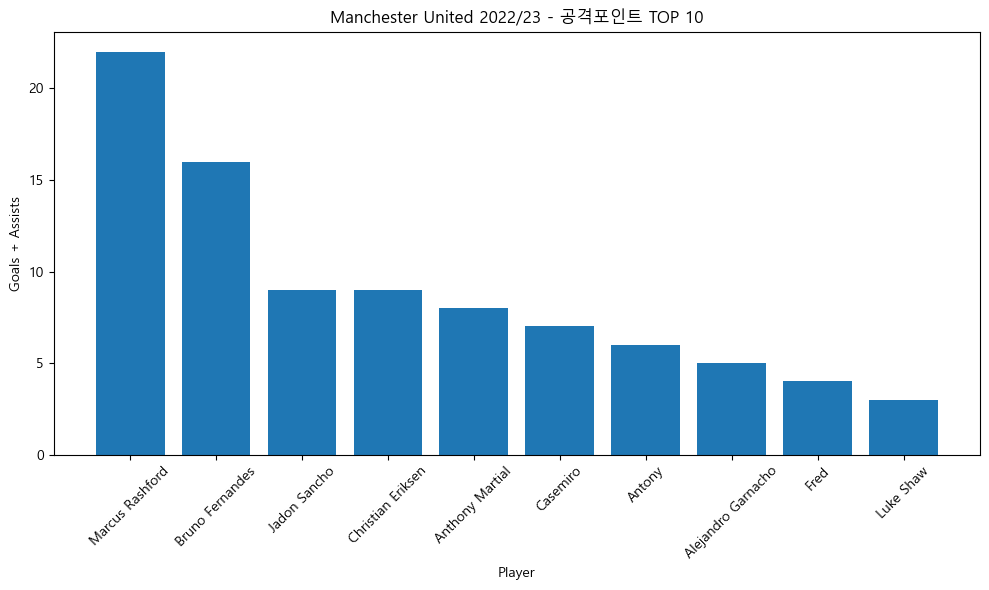

In [14]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

top10_attack=attack_df.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top10_attack["player"],
    top10_attack["attack_points"]
)

plt.title("Manchester United 2022/23 - 공격포인트 TOP 10")
plt.xlabel("Player")
plt.ylabel("Goals + Assists")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
#마커스래시포드는 22/23시즌 가장많은 공격포인트를 기록한 선수이다. 이 그래프는 득점과 도움 모두에서 높은 기여를 했다고 볼수있다.
#하지만 이 수치는 누적기록이기때문에 출전시간이 많은 선수일수록 유리하고, 슈팅 수나 슈팅 질 찬스메이킹 측면에서는 정확한 수치를 반영한 그래프는 아니다

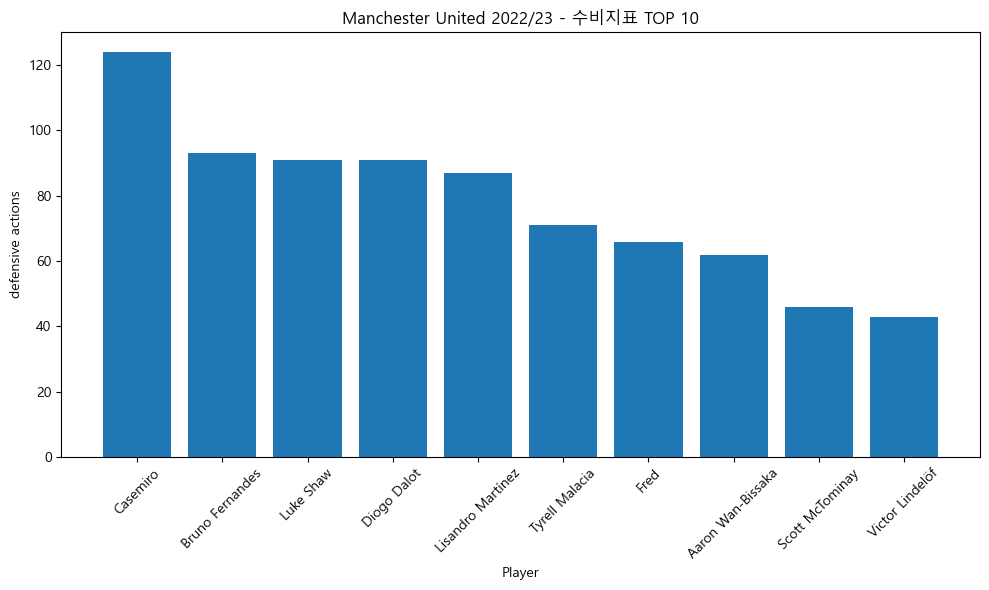

In [15]:
defense_df["defensive_actions"] = (
    defense_df["total_tackles"]
    + defense_df["total_interceptions"]
)
top10_defense = (
    defense_df
    .sort_values("defensive_actions", ascending=False)
    .head(10)
)
plt.figure(figsize=(10, 6))

plt.bar(
    top10_defense["player"],
    top10_defense["defensive_actions"]
)

plt.title("Manchester United 2022/23 - 수비지표 TOP 10")
plt.xlabel("Player")
plt.ylabel("defensive actions")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#위 그래프에서는 카세미루가 가장많은 수비지표를 기록했다. 총 태클수 및 총 인터셉트 수에서 많은 관여를 한거로 보여진다.
#하지만 위그래프는 출전시간에 따라 수치가 달라질수있고, 블록·경합·파울·카드와 같은 다른 수비 요소와 포지션별 역할 차이는 반영하지 않는다. 
#따라서 해당 그래프만으로 카세미루가 팀에서 가장 뛰어난 수비수였다고 단정하기는 어렵다.

In [ ]:
#22/23시즌 공격포인트를 가장 많이 기록한 선수는 마커스 래시포드이다. 골과 어시스트 합이 20개 이상으로 팀내 최다 공격포인트를 기록한 선수이다.
#수비지표에서는 카세미루가 가장 많이 기록한 선수이다. 태클과 인터셉트 수가 120회 이상으로 팀내 최다 수비행동을 기록한 선수이다.
#다만 이번 공격 지표는 득점과 어시스트 중심으로 구성되어 슈팅의 질을 나타내는 xG와 같은 요소를 포함하지 못했으며, 수비 지표 역시 태클과 인터셉트만을 사용해 경합, 블록, 파울 등 다른 수비 요소를 충분히 반영하지 않았다.
#또한 두 지표 모두 누적 기록이므로 출전시간이 많은 선수에게 유리할 수 있다. 포지션에 따라 선수에게 요구되는 역할 역시 다르기 때문에 단순 누적 수치만으로 선수의 전체적인 경기력을 판단하기는 어렵다.
#다음 분석에는 출전시간을 보장한 per90과 포지션별 비교를 적용할 필요가 있다.